In [8]:
import numpy as np
import pandas as pd
import joblib
import category_encoders as ce
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler, FunctionTransformer
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
from features import add_features
from sklearn.ensemble import RandomForestClassifier,StackingClassifier,GradientBoostingClassifier, AdaBoostClassifier
# from imblearn.pipeline import Pipeline
from imblearn.under_sampling import RandomUnderSampler
from sklearn.metrics import accuracy_score,ConfusionMatrixDisplay,confusion_matrix,classification_report,precision_recall_curve,f1_score
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

In [9]:
df = pd.read_csv("car_insurance_fraud_dataset.csv")
df.head()

,policy_id,policy_state,policy_deductible,policy_annual_premium,insured_age,insured_sex,insured_education_level,insured_occupation,insured_hobbies,incident_date,...,incident_state,incident_city,incident_hour_of_the_day,number_of_vehicles_involved,bodily_injuries,witnesses,police_report_available,claim_amount,total_claim_amount,fraud_reported
0,POL100000,GA,400,1430.78,74,OTHER,High School,Manager,reading,2024-06-13,...,MI,Charlesville,6,1,4,0,Yes,8161.36,11677.60,Y
1,POL100001,PA,300,854.49,74,MALE,College,Lawyer,chess,2025-03-23,...,OH,Joshuaberg,0,3,4,5,No,18561.79,18027.81,N
2,POL100002,MI,400,1247.28,28,OTHER,PhD,Doctor,reading,2025-01-26,...,MI,Reynoldsfurt,14,4,4,1,No,10734.61,10375.59,N
3,POL100003,CA,600,622.42,37,MALE,PhD,Teacher,yachting,2024-06-03,...,NC,Josephchester,22,3,3,5,No,13188.92,14204.34,N
4,POL100004,MI,700,1458.17,31,OTHER,PhD,Sales,reading,2024-05-21,...,NY,Caitlinfort,18,4,2,4,No,21864.69,24038.84,N


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 24 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   policy_id                    30000 non-null  object 
 1   policy_state                 30000 non-null  object 
 2   policy_deductible            30000 non-null  int64  
 3   policy_annual_premium        30000 non-null  float64
 4   insured_age                  30000 non-null  int64  
 5   insured_sex                  30000 non-null  object 
 6   insured_education_level      30000 non-null  object 
 7   insured_occupation           30000 non-null  object 
 8   insured_hobbies              30000 non-null  object 
 9   incident_date                30000 non-null  object 
 10  incident_type                30000 non-null  object 
 11  collision_type               30000 non-null  object 
 12  incident_severity            30000 non-null  object 
 13  authorities_cont

In [11]:
df.drop(columns='policy_id', inplace=True)
df['authorities_contacted'] = df['authorities_contacted'].fillna("No Contact")

X = df.drop(columns=[
    'fraud_reported','incident_date','policy_state',
    'incident_city','incident_state','insured_hobbies'
])

y = df['fraud_reported'].map({'Y':1,'N':0})


# **Check if target column is balanced or not**

In [12]:
target_counts = df['fraud_reported'].value_counts()
print("Class distribution:\n", target_counts)

target_percent = df['fraud_reported'].value_counts(normalize=True) * 100
print("\nClass distribution (%):\n", target_percent)

max_percent = target_percent.max()
min_percent = target_percent.min()

if max_percent - min_percent <= 20:
    print("\nTarget column is roughly balanced ✅")
else:
    print("\nTarget column is imbalanced ⚠️")

Class distribution:
 fraud_reported
N    26560
Y     3440
Name: count, dtype: int64

Class distribution (%):
 fraud_reported
N    88.533333
Y    11.466667
Name: proportion, dtype: float64

Target column is imbalanced ⚠️


In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, random_state=42
)

# **Undersampling**

In [14]:
rus = RandomUnderSampler(sampling_strategy=0.5, random_state=42)
X_train, y_train = rus.fit_resample(X_train, y_train)

# **Encoding**

In [15]:
categorical_col=df.select_dtypes('object')
for col in categorical_col:
  print(col,df[col].nunique())

policy_state 10
insured_sex 3
insured_education_level 4
insured_occupation 8
insured_hobbies 7
incident_date 731
incident_type 4
collision_type 4
incident_severity 3
authorities_contacted 4
incident_state 10
incident_city 17931
police_report_available 2
fraud_reported 2


In [16]:
ordinal_cols = ['insured_education_level','incident_severity']
target_cols = ['insured_occupation','age_group']

one_hot_cols = [
    'insured_sex','incident_type','collision_type','authorities_contacted'
]

numeric_cols = [
    'policy_deductible','policy_annual_premium','insured_age',
    'incident_hour_of_the_day','number_of_vehicles_involved',
    'bodily_injuries','witnesses','claim_amount','total_claim_amount','police_report_available'
]

In [ ]:
pd.crosstab(df['age_group'], df['fraud_reported'],normalize='index').plot(kind='bar')


In [17]:
ordinal_encoder = OrdinalEncoder(categories=[
    ['High School','College','Masters','PhD'],
    ['Minor Damage','Major Damage','Total Loss']
])

preprocessor = ColumnTransformer([
    ('onehot', OneHotEncoder(handle_unknown='ignore'), one_hot_cols),
    ('ordinal', ordinal_encoder, ordinal_cols),
    ('scale', StandardScaler(), numeric_cols)
])

# **Evaluation**

In [18]:
classifiers = {
    'SVM':SVC(class_weight='balanced',C=1,kernel='rbf',degree=3,gamma='scale',probability=True,tol=0.001,cache_size=200,random_state=42),
    'KNN':KNeighborsClassifier(n_jobs=-1),
    'Ada':AdaBoostClassifier(random_state=42),
    'Gradient':GradientBoostingClassifier(random_state=42),
    'RandomForest': RandomForestClassifier(n_estimators=300, max_depth=10, class_weight='balanced', random_state=42),
    'XGBoost': XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.1, scale_pos_weight=len(y[y==0])/len(y[y==1]), random_state=42),
    'lightgbm':lgb.LGBMClassifier( n_estimators=300,learning_rate=0.05,max_depth=6,num_leaves=31,random_state=42)
    
}

In [33]:
pipelines = {}

for name, classifier in classifiers.items():
    pipelines[name] = Pipeline([
        ('features', FunctionTransformer(add_features)),
        ('target_encode', ce.CatBoostEncoder(cols=target_cols)),
        ('preprocessing', preprocessor),
        ('classifier', classifier)
    ])

In [20]:
score={}
for name , pipeline in pipelines.items():
  pipeline.fit(X_train,y_train)
  y_pred = pipeline.predict(X_test)
  f1 = f1_score(y_test, y_pred)
  score[name] = f1
  print(f"=== {name} ===")
  print(classification_report(y_test, y_pred))


=== SVM ===
              precision    recall  f1-score   support

           0       0.94      0.70      0.81      6640
           1       0.22      0.65      0.33       860

    accuracy                           0.70      7500
   macro avg       0.58      0.68      0.57      7500
weighted avg       0.86      0.70      0.75      7500

=== KNN ===
              precision    recall  f1-score   support

           0       0.90      0.82      0.86      6640
           1       0.18      0.30      0.22       860

    accuracy                           0.76      7500
   macro avg       0.54      0.56      0.54      7500
weighted avg       0.82      0.76      0.79      7500

=== Ada ===
              precision    recall  f1-score   support

           0       0.91      0.92      0.91      6640
           1       0.30      0.26      0.28       860

    accuracy                           0.84      7500
   macro avg       0.60      0.59      0.60      7500
weighted avg       0.84      0.84     

c:\Users\nourh\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [21]:
pd.DataFrame.from_dict(score, orient='index', columns=['F1 Score']).sort_values(by='F1 Score', ascending=False)

,F1 Score
lightgbm,0.423324
Gradient,0.413657
RandomForest,0.366689
SVM,0.329286
XGBoost,0.305917
Ada,0.278154
KNN,0.222897


In [ ]:
stack = StackingClassifier(
    estimators=[
        ('rf', RandomForestClassifier(n_estimators=200,max_features= None,min_samples_leaf= 4,min_samples_split= 2,
        max_depth=20,
        class_weight='balanced',
        random_state=42)),
        ('gb', GradientBoostingClassifier(n_estimators=200,learning_rate=0.05,max_depth=5,subsample= 0.8,random_state=42)),
        ('lgb', lgb.LGBMClassifier(n_estimators=300,learning_rate=0.05,class_weight='balanced',random_state=42))
    ],
    final_estimator=XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.03,
        subsample=0.9,
        colsample_bytree=0.9,
        random_state=42
    ),
    stack_method='predict_proba',
    passthrough=False,
    n_jobs=-1,
    cv=5
)

In [35]:
model = Pipeline([
    ('features', FunctionTransformer(add_features)),
    ('target_encode', ce.CatBoostEncoder(cols=target_cols)),
    ('preprocessor', preprocessor),
    ('model', stack)
])

In [36]:
model.fit(X_train, y_train)

y_probs = model.predict_proba(X_test)[:,1]

precision, recall, thresholds = precision_recall_curve(y_test, y_probs)
f1 = 2*(precision*recall)/(precision+recall+1e-8)
best_threshold = thresholds[np.argmax(f1)]

c:\Users\nourh\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [37]:
print("\nClassification Report:\n", classification_report(y_test, y_pred))



Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.87      0.90      6640
           1       0.35      0.54      0.42       860

    accuracy                           0.83      7500
   macro avg       0.64      0.70      0.66      7500
weighted avg       0.87      0.83      0.85      7500



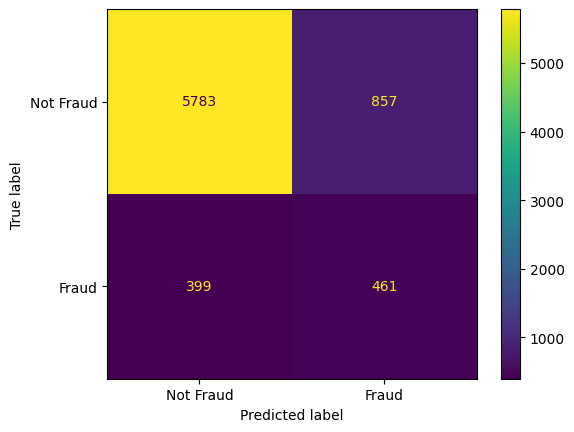

In [38]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=['Not Fraud','Fraud'])
disp.plot()

# **Saving Model**

In [ ]:
# joblib.dump(model, "model/fraud_model.pkl")
# joblib.dump(best_threshold, "model/threshold.pkl")

['model/threshold.pkl']